# Baseline Run Evaluation

This notebook compares the long-term baseline run and the target baseline run against available observations. It is designed to mirror the existing streamflow evaluation workflow while adding:

- optional linear-reservoir routing before streamflow comparison
- ET and SWE comparison against observation time series
- soil moisture and groundwater baseflow diagnostics
- user-defined time windows for plotting

In [1]:
import sys
from pathlib import Path
import os
# change to CONFLUENCE root directory
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / 'CONFLUENCE.py').exists():
    pass
elif (PROJECT_ROOT.parent / 'CONFLUENCE.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError('Run this notebook from the CONFLUENCE repository or one of its subfolders.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.custom import linear_reservoir

%matplotlib inline
plt.style.use('default')

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro


## Configuration

Set the config and experiment workspace first. If the baseline files are left as `None`, the notebook will try to detect them from the experiment directory.

In [19]:
EXPERIMENT_DIR = Path('/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/simulations/bigBuckt_elevationAspect_best_20260422_144322/output')
CONFIG_PATH = PROJECT_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_distributed_elevAspect.yaml'
TARGET_YEAR = 2021

# Optional manual file overrides (leave as None for auto-detect).
LONGTERM_BASELINE_FILE = None
TARGET_BASELINE_FILE = None
OBS_STREAMFLOW_CSV = '/scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/streamflow/preprocessed/East_River_distributed_streamflow_processed.csv'
OBS_ET_CSV = "/scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/et/openet_et_per_hru_distributed_monthly.csv"
OBS_SWE_CSV = "/scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/formatted/schofield_swe.csv"

# Observation value column names (if present).
ET_COLUMN = None
SWE_COLUMN = 'value'
SWE_OBS_IN_INCHES = False

# Optional linear reservoir post-processing and calibration settings.
RUNOFF_EVAL_VAR = 'basin__TotalRunoff'  # 'basin__TotalRunoff' or 'scalarTotalRunoff'
USE_LINEAR_RESERVOIR = True
FIT_LINEAR_RESERVOIR = True
RESERVOIR_METRIC = 'balanced'  # 'nse', 'kge', or 'log_nse'
RESERVOIR_PARAMS = {'k_fast': 0.08, 'k_slow': 0.005, 'f_fast': 0.9}
RESERVOIR_OPT_STRATEGY = 'adaptive'
RESERVOIR_OPT_STARTS = 300
RESERVOIR_OPT_SEED = 42

# ET/SWE HRU plotting options.
PLOT_HRU_ET_SWE = True
HRU_LINE_ALPHA = 0.35

# Optional run and time window filtering.
PLOT_RUNS = None  # Example: ['Long-term baseline']
PLOT_WINDOWS = [
    {'label': 'Full overlap', 'start': '2002-10-01', 'end': '2019-10-01'},
]

# Optional: initialize manual reservoir params from calibration output if present.
best_param_file = EXPERIMENT_DIR / 'settings' / 'best_parameters.csv'
if best_param_file.exists():
    best_df = pd.read_csv(best_param_file, index_col=0)
    required = {'k_fast', 'k_slow', 'f_fast'}
    if required.issubset(set(best_df.index)):
        RESERVOIR_PARAMS = {
            'k_fast': float(best_df.loc['k_fast', 'value']),
            'k_slow': float(best_df.loc['k_slow', 'value']),
            'f_fast': float(best_df.loc['f_fast', 'value']),
        }

print(f'Config path: {CONFIG_PATH}')
print(f'Experiment dir: {EXPERIMENT_DIR}')
print(f'Use linear reservoir: {USE_LINEAR_RESERVOIR}')
print(f'Fit linear reservoir: {FIT_LINEAR_RESERVOIR}')
print(f'Plot HRU ET/SWE: {PLOT_HRU_ET_SWE}')
print(f'Reservoir params: {RESERVOIR_PARAMS}')

Config path: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml
Experiment dir: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/simulations/bigBuckt_elevationAspect_best_20260422_144322/output
Use linear reservoir: True
Fit linear reservoir: True
Plot HRU ET/SWE: True
Reservoir params: {'k_fast': 0.08, 'k_slow': 0.005, 'f_fast': 0.9}


In [20]:
def load_config(config_path):
    config_path = Path(config_path)
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)


def resolve_project_dir(cfg):
    data_dir = Path(cfg['CONFLUENCE_DATA_DIR']).expanduser()
    return data_dir / f"domain_{cfg['DOMAIN_NAME']}"


def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def detect_baseline_files(experiment_dir, target_year):
    experiment_dir = Path(experiment_dir)
    if not experiment_dir.exists():
        raise FileNotFoundError(f'Experiment directory not found: {experiment_dir}')

    longterm_candidates = [
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'baseline_longterm_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'longterm_baseline_timestep.nc',
    ]
    target_candidates = [
        experiment_dir / 'ensemble' / 'results' / 'baseline' / f'target_wy_{target_year}_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_target' / f'target_wy_{target_year}_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_target' / f'target_year_{target_year}_timestep.nc',
    ]

    longterm_file = first_existing(longterm_candidates)
    target_file = first_existing(target_candidates)

    if longterm_file is None:
        raise FileNotFoundError('Could not auto-detect long-term baseline netCDF.')
    return longterm_file, target_file


def autodetect_streamflow_csv(project_dir, domain_name):
    preferred = project_dir / 'observations' / 'streamflow' / 'preprocessed' / f'{domain_name}_streamflow_processed.csv'
    if preferred.exists():
        return preferred
    candidates = sorted((project_dir / 'observations' / 'streamflow' / 'preprocessed').glob('*_streamflow_processed.csv'))
    return candidates[0] if candidates else None


def autodetect_et_csv(project_dir):
    et_dir = project_dir / 'observations' / 'et'
    if not et_dir.exists():
        return None
    for pattern in ['*openet*.csv', '*et*.csv', '*.csv']:
        matches = sorted(et_dir.glob(pattern))
        if matches:
            return matches[0]
    return None


def autodetect_swe_csv(project_dir):
    snow_dir = project_dir / 'observations' / 'snow'
    if not snow_dir.exists():
        return None
    for pattern in ['*sntl*.csv', '*SNTL*.csv', '*swe*.csv', '*.csv']:
        matches = sorted(snow_dir.glob(pattern))
        if matches:
            return matches[0]
    return None


def detect_time_column(df):
    for c in ['datetime', 'date', 'time', 'Date', 'DATE']:
        if c in df.columns:
            return c
    raise KeyError('No time column found in CSV.')


def choose_numeric_column(df, preferred=None):
    if preferred and preferred in df.columns:
        return preferred
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise ValueError('No numeric column found in CSV.')
    return numeric_cols[0]


def load_observed_series(csv_path, preferred_column=None, monthly=False):
    df = pd.read_csv(csv_path)
    time_col = detect_time_column(df)
    value_col = choose_numeric_column(df, preferred_column)
    series = df[[time_col, value_col]].copy()
    series[time_col] = pd.to_datetime(series[time_col])
    series = series.set_index(time_col)[value_col].sort_index()
    if monthly:
        series = series.resample('MS').mean()
    return series


def basin_area_from_attributes(cfg, project_dir):
    attrs_file = project_dir / 'settings' / 'SUMMA' / cfg.get('SETTINGS_SUMMA_ATTRIBUTES', 'attributes.nc')
    if not attrs_file.exists():
        raise FileNotFoundError(f'attributes.nc not found: {attrs_file}')
    with xr.open_dataset(attrs_file) as ds:
        if 'HRUarea' not in ds:
            raise KeyError(f'HRUarea missing in {attrs_file}')
        return float(ds['HRUarea'].sum())


def get_hru_coords(ds):
    if 'hru' in ds.coords:
        return ds['hru'].values
    for key in ['hruId', 'hru_id', 'HRU_ID']:
        if key in ds.variables:
            return ds[key].values
    return None


def get_hru_area_series(ds):
    if 'HRUarea' not in ds:
        return None
    area = ds['HRUarea'].squeeze().to_pandas()
    if isinstance(area, pd.DataFrame):
        area = area.iloc[:, 0]
    hru_vals = get_hru_coords(ds)
    if hru_vals is not None and len(hru_vals) == len(area):
        area.index = [str(int(v)) if str(v).replace('.', '', 1).isdigit() else str(v) for v in hru_vals]
    else:
        area.index = [str(i + 1) for i in range(len(area))]
    return area.astype(float)


def to_time_series(da, agg='mean'):
    if 'hru' in da.dims:
        da = da.mean(dim='hru') if agg == 'mean' else da.sum(dim='hru')
    if 'gru' in da.dims:
        da = da.mean(dim='gru') if agg == 'mean' else da.sum(dim='gru')
    out = da.squeeze().to_pandas()
    if isinstance(out, pd.DataFrame):
        out = out.mean(axis=1) if agg == 'mean' else out.sum(axis=1)
    out.index = pd.to_datetime(out.index)
    return out


def to_hru_dataframe(da):
    if 'gru' in da.dims:
        da = da.mean(dim='gru')
    out = da.squeeze().to_pandas()
    if isinstance(out, pd.Series):
        out = out.to_frame(name='1')
    if out.index.nlevels > 1:
        out = out.unstack()
    hru_vals = get_hru_coords(da.to_dataset(name='tmp')) if hasattr(da, 'to_dataset') else None
    if hru_vals is not None and out.shape[1] == len(hru_vals):
        out.columns = [str(int(v)) if str(v).replace('.', '', 1).isdigit() else str(v) for v in hru_vals]
    else:
        out.columns = [str(c) for c in out.columns]
    out.index = pd.to_datetime(out.index)
    return out


def area_weighted_from_hru_df(hru_df, area_series):
    common = [c for c in hru_df.columns if c in area_series.index]
    if not common:
        return hru_df.mean(axis=1)
    weights = area_series.loc[common].astype(float)
    weighted = hru_df[common].mul(weights, axis=1).sum(axis=1) / weights.sum()
    return weighted


def runoff_to_discharge(ds, basin_area_m2):
    if RUNOFF_EVAL_VAR in ds:
        runoff_da = ds[RUNOFF_EVAL_VAR]
    else:
        raise KeyError(f"Missing runoff variable ({RUNOFF_EVAL_VAR}).")
    runoff = to_time_series(runoff_da, agg='mean')
    return runoff * basin_area_m2


def apply_linear_reservoir(discharge_series, params):
    routed = linear_reservoir.two_reservoir_daily(
        q_in=discharge_series.values,
        k_fast=params['k_fast'],
        k_slow=params['k_slow'],
        f=params['f_fast'],
    )
    return pd.Series(routed, index=discharge_series.index, name=discharge_series.name)


def fit_linear_reservoir(raw_daily, obs_daily, metric='nse', strategy='adaptive', n_starts=200, seed=42):
    obs_aligned, sim_aligned = align_series(obs_daily, raw_daily)
    results = linear_reservoir.calibrate_reservoirs(
        q_in=sim_aligned.values,
        obs=obs_aligned.values,
        metric=metric,
        strategy=strategy,
        n_starts=n_starts,
        seed=seed,
        metric_weights={'w_kge': 0.3, 'w_nse': 0.2, 'w_kge_log': 0.3, 'w_nse_log': 0.2} if metric == 'balanced' else None,
    )
    return {
        'k_fast': float(results['k_fast']),
        'k_slow': float(results['k_slow']),
        'f_fast': float(results['f_fast']),
    }


def get_et_series(ds):
    if 'scalarTotalET' not in ds:
        return None
    et_da = ds['scalarTotalET']
    if 'scalarSnowSublimation' in ds:
        et_da = et_da + ds['scalarSnowSublimation']
    et = to_time_series(et_da, agg='mean')
    return (-et * 3600.0).resample('MS').sum()


def get_et_hru_df(ds):
    if 'scalarTotalET' not in ds:
        return None
    et_da = ds['scalarTotalET']
    if 'scalarSnowSublimation' in ds:
        et_da = et_da + ds['scalarSnowSublimation']
    et_hru = to_hru_dataframe(et_da)
    return (-et_hru * 3600.0).resample('MS').sum()


def get_swe_series(ds):
    if 'scalarSWE' not in ds:
        return None
    swe = to_time_series(ds['scalarSWE'], agg='mean')
    return swe.resample('D').mean()


def get_swe_hru_df(ds):
    if 'scalarSWE' not in ds:
        return None
    swe_hru = to_hru_dataframe(ds['scalarSWE'])
    return swe_hru.resample('D').mean()


def clip_series(series, start, end):
    if series is None:
        return None
    return series.loc[pd.Timestamp(start):pd.Timestamp(end)]


def align_series(obs_series, sim_series):
    if isinstance(obs_series, pd.DataFrame):
        obs_series = obs_series.mean(axis=1)
    if isinstance(sim_series, pd.DataFrame):
        sim_series = sim_series.mean(axis=1)
    joined = pd.concat([obs_series.rename('obs'), sim_series.rename('sim')], axis=1).dropna()
    return joined['obs'], joined['sim']


def get_overlap_window(obs_series, sim_series_dict):
    starts = [obs_series.index.min()]
    ends = [obs_series.index.max()]
    for s in sim_series_dict.values():
        starts.append(s.index.min())
        ends.append(s.index.max())
    return max(starts), min(ends)


def compute_metrics(obs_series, sim_series):
    obs_aligned, sim_aligned = align_series(obs_series, sim_series)
    if len(obs_aligned) == 0:
        return None
    rmse = float(np.sqrt(np.mean((sim_aligned - obs_aligned) ** 2)))
    nse = float(linear_reservoir.nse(obs_aligned.values, sim_aligned.values))
    kge = float(linear_reservoir.kge(obs_aligned.values, sim_aligned.values))
    log_nse = float(linear_reservoir.log_nse(obs_aligned.values, sim_aligned.values))
    return {'n': int(len(obs_aligned)), 'rmse': rmse, 'nse': nse, 'kge': kge, 'log_nse': log_nse}

In [21]:
if CONFIG_PATH is not None and Path(CONFIG_PATH).exists():
    config_path_used = Path(CONFIG_PATH)
else:
    config_candidates = sorted(EXPERIMENT_DIR.glob('config_*.yaml'))
    if not config_candidates:
        config_candidates = sorted(EXPERIMENT_DIR.parent.glob('config_*.yaml'))
    if not config_candidates:
        fallback = PROJECT_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_singleGRU_elevation5.yaml'
        if fallback.exists():
            config_path_used = fallback
        else:
            raise FileNotFoundError(
                f'No config_*.yaml found in {EXPERIMENT_DIR} or {EXPERIMENT_DIR.parent}, and fallback missing: {fallback}'
            )
    else:
        config_path_used = config_candidates[-1]

cfg = load_config(config_path_used)
project_dir = resolve_project_dir(cfg)
domain_name = cfg['DOMAIN_NAME']
basin_area_m2 = basin_area_from_attributes(cfg, project_dir)

if LONGTERM_BASELINE_FILE is None or TARGET_BASELINE_FILE is None:
    try:
        auto_longterm, auto_target = detect_baseline_files(EXPERIMENT_DIR, TARGET_YEAR)
    except FileNotFoundError:
        # Fallback for simple smoke runs that write a single timestep output in EXPERIMENT_DIR.
        generic_timestep = sorted(EXPERIMENT_DIR.glob('*timestep.nc'))
        if not generic_timestep:
            generic_timestep = sorted(EXPERIMENT_DIR.rglob('*timestep.nc'))
        if not generic_timestep:
            raise
        auto_longterm = generic_timestep[0]
        auto_target = None

    longterm_file = auto_longterm if LONGTERM_BASELINE_FILE is None else Path(LONGTERM_BASELINE_FILE)
    target_file = auto_target if TARGET_BASELINE_FILE is None else Path(TARGET_BASELINE_FILE)
else:
    longterm_file = Path(LONGTERM_BASELINE_FILE)
    target_file = Path(TARGET_BASELINE_FILE)

obs_streamflow_path = Path(OBS_STREAMFLOW_CSV) if OBS_STREAMFLOW_CSV else autodetect_streamflow_csv(project_dir, domain_name)
obs_et_path = Path(OBS_ET_CSV) if OBS_ET_CSV else autodetect_et_csv(project_dir)
obs_swe_path = Path(OBS_SWE_CSV) if OBS_SWE_CSV else autodetect_swe_csv(project_dir)

if obs_streamflow_path is None or not obs_streamflow_path.exists():
    raise FileNotFoundError('Observed streamflow CSV could not be found.')

obs_streamflow = load_observed_series(obs_streamflow_path, preferred_column='discharge_cms', monthly=False).resample('1D').mean()
obs_et = load_observed_series(obs_et_path, preferred_column=ET_COLUMN, monthly=True) if obs_et_path and obs_et_path.exists() else None
obs_swe = load_observed_series(obs_swe_path, preferred_column=SWE_COLUMN, monthly=False) if obs_swe_path and obs_swe_path.exists() else None

if obs_swe is not None and SWE_OBS_IN_INCHES:
    obs_swe = obs_swe * 25.4
if obs_swe is not None:
    obs_swe = obs_swe.resample('1D').mean()

run_datasets = {'Long-term baseline': xr.open_dataset(longterm_file)}
if target_file is not None and Path(target_file).exists():
    run_datasets['Target baseline'] = xr.open_dataset(target_file)

dataset_store = {
    'config_path': config_path_used,
    'config': cfg,
    'project_dir': project_dir,
    'files': {'longterm': longterm_file, 'target': target_file},
    'datasets': run_datasets,
    'variables': {name: sorted(list(ds.data_vars)) for name, ds in run_datasets.items()},
}

hru_areas = {name: get_hru_area_series(ds) for name, ds in run_datasets.items()}
et_monthly_hru = {name: get_et_hru_df(ds) for name, ds in run_datasets.items()}
swe_daily_hru = {name: get_swe_hru_df(ds) for name, ds in run_datasets.items()}

et_monthly = {}
swe_daily = {}
for name in run_datasets:
    et_hru_df = et_monthly_hru.get(name)
    swe_hru_df = swe_daily_hru.get(name)
    area = hru_areas.get(name)

    if et_hru_df is not None and area is not None:
        et_monthly[name] = area_weighted_from_hru_df(et_hru_df, area)
    else:
        et_monthly[name] = get_et_series(run_datasets[name])

    if swe_hru_df is not None and area is not None:
        swe_daily[name] = area_weighted_from_hru_df(swe_hru_df, area)
    else:
        swe_daily[name] = get_swe_series(run_datasets[name])

dataset_store['hru_areas'] = hru_areas
dataset_store['et_monthly_hru'] = et_monthly_hru
dataset_store['swe_daily_hru'] = swe_daily_hru
dataset_store['et_monthly_area_weighted'] = et_monthly
dataset_store['swe_daily_area_weighted'] = swe_daily

streamflow_raw_daily = {
    name: runoff_to_discharge(ds, basin_area_m2).resample('1D').mean()
    for name, ds in run_datasets.items()
}

reservoir_params_used = None
if USE_LINEAR_RESERVOIR:
    if FIT_LINEAR_RESERVOIR:
        reservoir_params_used = fit_linear_reservoir(
            streamflow_raw_daily['Long-term baseline'],
            obs_streamflow,
            metric=RESERVOIR_METRIC,
            strategy=RESERVOIR_OPT_STRATEGY,
            n_starts=RESERVOIR_OPT_STARTS,
            seed=RESERVOIR_OPT_SEED,
        )
    else:
        reservoir_params_used = dict(RESERVOIR_PARAMS)
    streamflow_daily = {
        name: apply_linear_reservoir(series, reservoir_params_used)
        for name, series in streamflow_raw_daily.items()
    }
else:
    streamflow_daily = streamflow_raw_daily

available_runs = list(run_datasets.keys())
if PLOT_RUNS is None:
    run_names_to_plot = available_runs
else:
    run_names_to_plot = [name for name in PLOT_RUNS if name in available_runs]
if not run_names_to_plot:
    raise ValueError(f'PLOT_RUNS matched no runs. Available runs: {available_runs}')

overlap_start, overlap_end = get_overlap_window(obs_streamflow, {k: streamflow_daily[k] for k in run_names_to_plot})
resolved_plot_windows = []
for w in PLOT_WINDOWS:
    resolved_plot_windows.append({
        'label': w.get('label', 'Window'),
        'start': w.get('start') or str(overlap_start.date()),
        'end': w.get('end') or str(overlap_end.date()),
    })

summary_rows = []
for run_name in run_names_to_plot:
    m = compute_metrics(
        clip_series(obs_streamflow, resolved_plot_windows[0]['start'], resolved_plot_windows[0]['end']),
        clip_series(streamflow_daily[run_name], resolved_plot_windows[0]['start'], resolved_plot_windows[0]['end']),
    )
    row = {'run': run_name}
    if m is not None:
        row.update(m)
    summary_rows.append(row)

variable_rows = []
for run_name, vars_list in dataset_store['variables'].items():
    variable_rows.append({
        'run': run_name,
        'n_variables': len(vars_list),
        'sample_variables': ', '.join(vars_list[:12]),
    })

print('Loaded data summary:')
print(f'  Config used: {config_path_used}')
print(f'  Project dir: {project_dir}')
print(f'  Basin area (SUMMA HRUarea): {basin_area_m2/1e6:,.2f} km^2')
print(f'  Long-term file: {longterm_file}')
print(f'  Target file: {target_file if target_file is not None else "<not found>"}')
print(f'  Streamflow obs: {obs_streamflow_path}')
print(f'  ET obs: {obs_et_path if obs_et_path else "<not found>"}')
print(f'  SWE obs: {obs_swe_path if obs_swe_path else "<not found>"}')
print(f'  Runs to plot: {run_names_to_plot}')
print(f'  Plot windows: {resolved_plot_windows}')
if reservoir_params_used is not None:
    print(f'  Linear reservoir params used: {reservoir_params_used}')
print("\nDataset store quick access:")
print("  dataset_store['datasets']['Long-term baseline']")
print("  dataset_store['variables']['Long-term baseline']")
print("  dataset_store['et_monthly_hru']['Long-term baseline'].head()")
print("  dataset_store['swe_daily_hru']['Long-term baseline'].head()")

display(pd.DataFrame(summary_rows))
display(pd.DataFrame(variable_rows))

Loaded data summary:
  Config used: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml
  Project dir: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect
  Basin area (SUMMA HRUarea): 748.25 km^2
  Long-term file: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/simulations/bigBuckt_elevationAspect_best_20260422_144322/output/bigBuckt_distributed_elevAspect_best_timestep.nc
  Target file: <not found>
  Streamflow obs: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/streamflow/preprocessed/East_River_distributed_streamflow_processed.csv
  ET obs: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/et/openet_et_per_hru_distributed_monthly.csv
  SWE obs: /scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/formatted/schofield_swe.csv
  Runs to plot: ['Long-term baseline']
  Plot window

,run,n,rmse,nse,kge,log_nse
0,Long-term baseline,6210,6.568096,0.741161,0.837183,0.847156


,run,n_variables,sample_variables
0,Long-term baseline,56,"LWRadAtm, SWRadAtm, airtemp, averageInstantRun..."


## Streamflow Plots

Hydrograph and flow-duration curves for each selected run and time window.

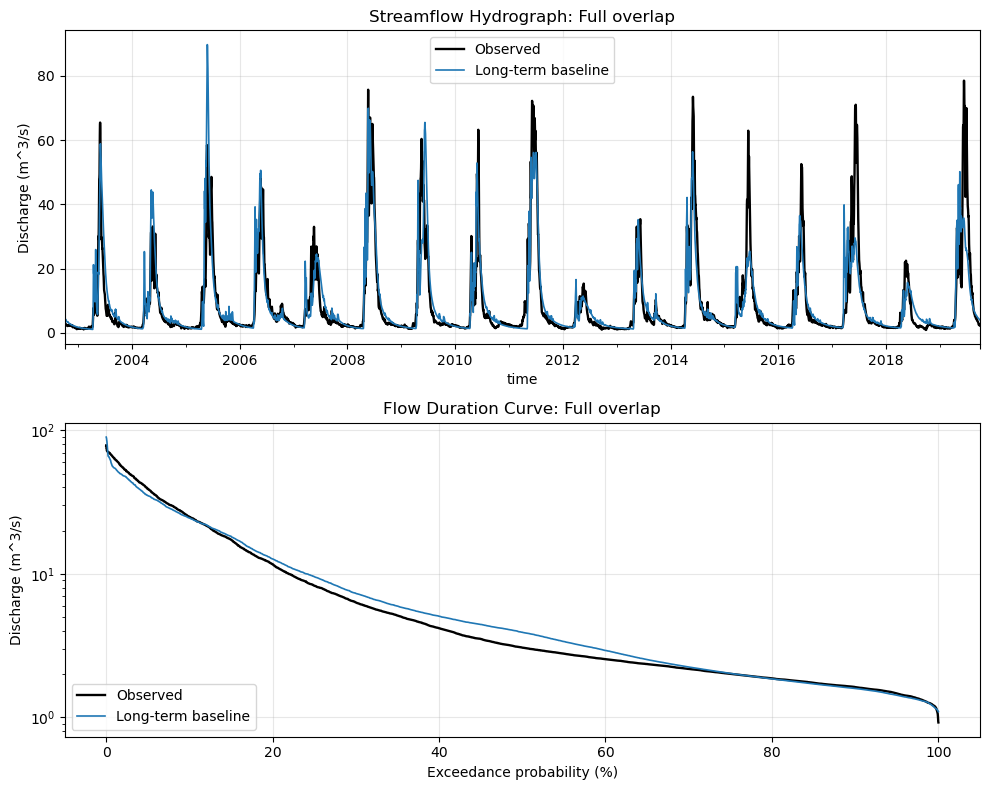

Metrics (Full overlap):
  Long-term baseline: n=6210, RMSE=6.568, NSE=0.741, KGE=0.837, logNSE=0.847


In [23]:
for window in resolved_plot_windows:
    start = window['start']
    end = window['end']
    label = window['label']

    obs_window = clip_series(obs_streamflow, start, end).resample('1D').mean()
    sim_windows = {
        name: clip_series(streamflow_daily[name], start, end).resample('1D').mean()
        for name in run_names_to_plot
    }

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

    # Hydrograph
    ax = axes[0]
    obs_window.plot(ax=ax, color='black', linewidth=1.7, label='Observed')
    for name, series in sim_windows.items():
        series.plot(ax=ax, linewidth=1.2, label=name)
    ax.set_title(f'Streamflow Hydrograph: {label}')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Flow duration curve
    ax = axes[1]
    obs_sorted = obs_window.sort_values(ascending=False)
    obs_rank = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted) * 100.0
    ax.semilogy(obs_rank, obs_sorted.values, color='black', linewidth=1.7, label='Observed')
    for name, series in sim_windows.items():
        sorted_series = series.sort_values(ascending=False)
        rank = np.arange(1, len(sorted_series) + 1) / len(sorted_series) * 100.0
        ax.semilogy(rank, sorted_series.values, linewidth=1.2, label=name)
    ax.set_title(f'Flow Duration Curve: {label}')
    ax.set_xlabel('Exceedance probability (%)')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    print(f'Metrics ({label}):')
    for run_name in run_names_to_plot:
        m = compute_metrics(obs_window, sim_windows[run_name])
        if m is None:
            print(f'  {run_name}: no overlap')
            continue
        print(
            f"  {run_name}: n={m['n']}, RMSE={m['rmse']:.3f}, "
            f"NSE={m['nse']:.3f}, KGE={m['kge']:.3f}, logNSE={m['log_nse']:.3f}"
        )

<Axes: title={'center': 'gru = 1 [-]'}, xlabel='datetime', ylabel='averageRoutedRunoff'>

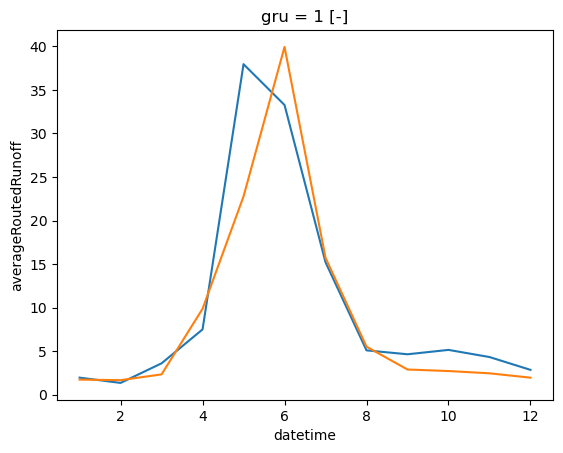

In [49]:
(dataset_store['datasets']['Long-term baseline']['averageRoutedRunoff'].groupby('time.month').mean()*basin_area_m2).plot()
obs_window.groupby(obs_window.index.month).mean().plot()

## ET and SWE Plots

Monthly ET and daily SWE comparison against available observations.

In [25]:
butte_swe = pd.read_csv('/scratch/dlhogan/ess-project-data/domain_East_River_distributed/observations/formatted/snotel_swe.csv', index_col=0, parse_dates=True)

/tmp/ipykernel_3163294/4257933382.py:86: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax_swe.plot(


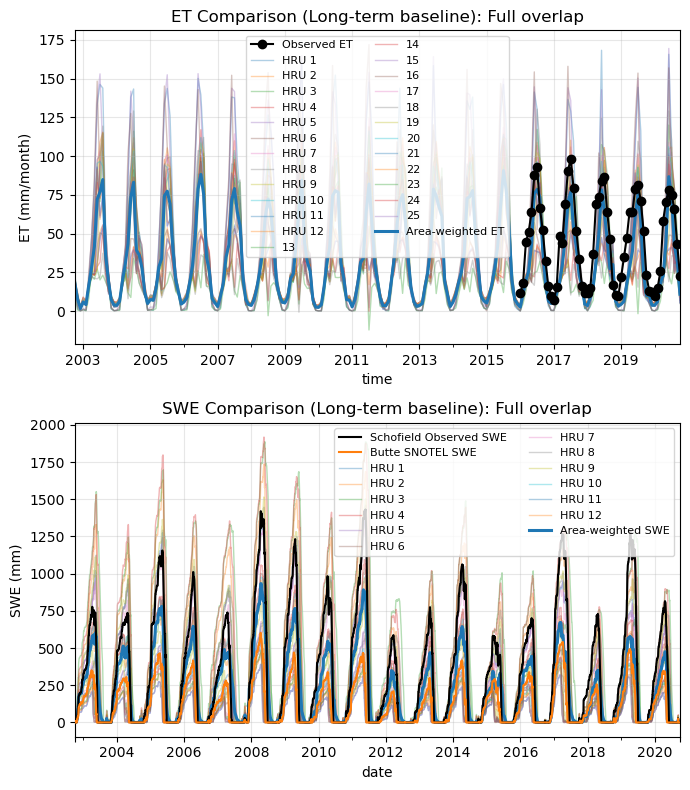

In [26]:
for window in resolved_plot_windows:
    start = window['start']
    end = window['end']
    label = window['label']

    n_runs = len(run_names_to_plot)
    fig, axes = plt.subplots(2, n_runs, figsize=(7 * n_runs, 8), sharex=False)
    if n_runs == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for col, run_name in enumerate(run_names_to_plot):
        # # ET panel (monthly)
        ax_et = axes[0, col]
        if obs_et is not None:
            obs_et_window = clip_series(obs_et, start, end)
            obs_et_window.index = pd.to_datetime(obs_et_window.index)
            if len(obs_et_window) > 0:
                obs_et_window.plot(
                    ax=ax_et,
                    color='black',
                    marker='o',
                    linewidth=1.5,
                    label='Observed ET',
                    zorder=3,
                )

        et_hru_df = et_monthly_hru.get(run_name)
        if PLOT_HRU_ET_SWE and et_hru_df is not None:
            et_hru_window = clip_series(et_hru_df, start, end)
            if isinstance(et_hru_window, pd.DataFrame) and len(et_hru_window) > 0:
                for i, hru_col in enumerate(et_hru_window.columns):
                    hru_label = f'HRU {hru_col}' if i < 12 else None
                    et_hru_window[hru_col].plot(
                        ax=ax_et,
                        linewidth=1.0,
                        alpha=HRU_LINE_ALPHA,
                        label=hru_label,
                        zorder=1,
                    )

        et_aw = et_monthly.get(run_name)
        if et_aw is not None:
            et_aw_window = clip_series(et_aw, start, end)
            if len(et_aw_window) > 0:
                et_aw_window.plot(
                    ax=ax_et,
                    color='tab:blue',
                    linewidth=2.2,
                    label='Area-weighted ET',
                    zorder=2,
                )

        ax_et.set_title(f'ET Comparison ({run_name}): {label}')
        ax_et.set_ylabel('ET (mm/month)')
        ax_et.grid(True, alpha=0.3)
        ax_et.legend(fontsize=8, ncol=2)

        # SWE panel (daily)
        ax_swe = axes[1, col]
        if obs_swe is not None:
            obs_swe_window = clip_series(obs_swe, start, end)
            butte_swe_window = clip_series(butte_swe['value'], start, end)
            if len(obs_swe_window) > 0:
                obs_swe_window.plot(
                    ax=ax_swe,
                    color='black',
                    linewidth=1.5,
                    label='Schofield Observed SWE',
                    zorder=3,
                )
            if len(butte_swe_window) > 0:
                    butte_swe_window.plot(
                        ax=ax_swe,
                        color='tab:orange',
                        linewidth=1.5,
                        label='Butte SNOTEL SWE',
                        zorder=4,
                    )

        swe_hru_df = swe_daily_hru.get(run_name)
        if PLOT_HRU_ET_SWE and swe_hru_df is not None:
            swe_hru_window = clip_series(swe_hru_df, start, end)
            if isinstance(swe_hru_window, pd.DataFrame) and len(swe_hru_window) > 0:
                for i, hru_col in enumerate(swe_hru_window.columns):
                    hru_label = f'HRU {hru_col}' if i < 12 else None
                    ax_swe.plot(
                        swe_hru_window.index,
                        swe_hru_window[hru_col].values,
                        linewidth=1.0,
                        alpha=HRU_LINE_ALPHA,
                        label=hru_label,
                        zorder=1,
                    )

        swe_aw = swe_daily.get(run_name)
        if swe_aw is not None:
            swe_aw_window = clip_series(swe_aw, start, end)
            if len(swe_aw_window) > 0:
                ax_swe.plot(
                    swe_aw_window.index,
                    swe_aw_window.values,
                    color='tab:blue',
                    linewidth=2.2,
                    label='Area-weighted SWE',
                    zorder=2,
                )

        ax_swe.set_title(f'SWE Comparison ({run_name}): {label}')
        ax_swe.set_ylabel('SWE (mm)')
        ax_swe.grid(True, alpha=0.3)
        ax_swe.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()